In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-wheat-detection/sample_submission.csv
/kaggle/input/global-wheat-detection/train.csv
/kaggle/input/global-wheat-detection/test/796707dd7.jpg
/kaggle/input/global-wheat-detection/test/2fd875eaa.jpg
/kaggle/input/global-wheat-detection/test/cc3532ff6.jpg
/kaggle/input/global-wheat-detection/test/53f253011.jpg
/kaggle/input/global-wheat-detection/test/f5a1f0358.jpg
/kaggle/input/global-wheat-detection/test/51f1be19e.jpg
/kaggle/input/global-wheat-detection/test/aac893a91.jpg
/kaggle/input/global-wheat-detection/test/cb8d261a3.jpg
/kaggle/input/global-wheat-detection/test/51b3e36ab.jpg
/kaggle/input/global-wheat-detection/test/348a992bb.jpg
/kaggle/input/global-wheat-detection/train/944c60a15.jpg
/kaggle/input/global-wheat-detection/train/dd5dd0234.jpg
/kaggle/input/global-wheat-detection/train/72f8aaa4f.jpg
/kaggle/input/global-wheat-detection/train/69595016d.jpg
/kaggle/input/global-wheat-detection/train/28b8ba0aa.jpg
/kaggle/input/global-wheat-detection/train/2d6357

In [2]:
# Standard library imports
import os  # For handling file paths
import random  # For generating random numbers
from collections import Counter  # For counting hashable objects

# Third-party imports
import numpy as np  # For numerical operations
import pandas as pd  # For data manipulation and analysis
from PIL import Image, ImageDraw  # For image handling and drawing
import matplotlib.pyplot as plt  # For plotting
from sklearn.model_selection import train_test_split  # For splitting data into training and testing sets

# PyTorch imports
import torch  # For tensor operations and neural networks
import torchvision  # For computer vision tasks

# Torchvision imports
from torchvision import transforms as T  # For data transformations
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor  # For Faster R-CNN model


In [3]:
train = pd.read_csv("/kaggle/input/global-wheat-detection/train.csv")
train.head()

,image_id,width,height,bbox,source
0,b6ab77fd7,1024,1024,"[834.0, 222.0, 56.0, 36.0]",usask_1
1,b6ab77fd7,1024,1024,"[226.0, 548.0, 130.0, 58.0]",usask_1
2,b6ab77fd7,1024,1024,"[377.0, 504.0, 74.0, 160.0]",usask_1
3,b6ab77fd7,1024,1024,"[834.0, 95.0, 109.0, 107.0]",usask_1
4,b6ab77fd7,1024,1024,"[26.0, 144.0, 124.0, 117.0]",usask_1


In [4]:
coord = pd.DataFrame(list(train.bbox.apply(lambda x : x[1:-1].split(",")).values),columns=["x1","y1","w","h"])

In [5]:
df = pd.concat([train,coord],axis=1)

In [6]:
df['x1']=pd.to_numeric(df['x1'])
df['y1']=pd.to_numeric(df['y1'])
df['w']=pd.to_numeric(df['w'])
df['h']=pd.to_numeric(df['h'])

In [7]:
df['x2']=df['x1']+df['w']
df['y2']=df['y1']+df['h']

In [8]:
df.drop(['bbox','width','height','w','h','source'],axis=1,inplace=True)

In [9]:
df.head()

,image_id,x1,y1,x2,y2
0,b6ab77fd7,834.0,222.0,890.0,258.0
1,b6ab77fd7,226.0,548.0,356.0,606.0
2,b6ab77fd7,377.0,504.0,451.0,664.0
3,b6ab77fd7,834.0,95.0,943.0,202.0
4,b6ab77fd7,26.0,144.0,150.0,261.0


In [10]:
unique_imgs=df.image_id.unique()
unique_imgs

array(['b6ab77fd7', 'b53afdf5c', '7b72ea0fb', ..., 'a5c8d5f5c',
       'e6b5e296d', '5e0747034'], dtype=object)

In [11]:
# Define a custom dataset class inheriting from torch.utils.data.Dataset
class custDat(torch.utils.data.Dataset):
    def __init__(self, df, unique_imgs, indices):
        """
        Initialize the dataset with a DataFrame, a list of unique image names, and indices.
        
        Args:
            df (pd.DataFrame): DataFrame containing image IDs and bounding box information.
            unique_imgs (list): List of unique image names.
            indices (list): List of indices to be used for accessing the dataset.
        """
        self.df = df  # DataFrame containing image and bounding box data
        self.unique_imgs = unique_imgs  # List of unique image names
        self.indices = indices  # Indices for accessing the images in the dataset
    
    def __len__(self):
        """
        Return the length of the dataset.
        
        Returns:
            int: Number of samples in the dataset.
        """
        return len(self.indices)  # Length of the dataset based on the indices
    
    def __getitem__(self, idx):
        """
        Get an item from the dataset at the specified index.
        
        Args:
            idx (int): Index of the item to be fetched.
        
        Returns:
            tuple: Tuple containing the image tensor and the target dictionary.
        """
        # Get the image name using the index
        image_name = self.unique_imgs[self.indices[idx]]
        
        # Get the bounding boxes for the image
        boxes = self.df[self.df.image_id == image_name].values[:, 1:].astype("float")
        
        # Open the image and convert it to RGB format
        img = Image.open("../input/global-wheat-detection/train/" + image_name + ".jpg").convert('RGB')
        
        # Create labels tensor with value 1 for each bounding box
        labels = torch.ones(boxes.shape[0], dtype=torch.int64)
        
        # Create the target dictionary containing boxes and labels
        target = {}
        target["boxes"] = torch.tensor(boxes)  # Bounding boxes as a tensor
        target["label"] = labels  # Labels as a tensor
        
        # Return the image converted to a tensor and the target dictionary
        return T.ToTensor()(img), target


In [12]:
train_inds , val_inds =train_test_split(range(unique_imgs.shape[0]),test_size=0.1)

In [13]:
def custom_collate(data):
    return data

In [14]:
train_dl = torch.utils.data.DataLoader(custDat(df,unique_imgs,train_inds),
                                       batch_size=16,
                                       shuffle=True,
                                       collate_fn=custom_collate,
                                       pin_memory=True if torch.cuda.is_available() else False)
val_dl = torch.utils.data.DataLoader(custDat(df,unique_imgs,val_inds),
                                     batch_size=8,
                                     shuffle=True,
                                     collate_fn=custom_collate,
                                     pin_memory=True if torch.cuda.is_available() else False)

In [15]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=True)

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 166MB/s]  


In [16]:
model

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [17]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [18]:
device

device(type='cuda')

In [19]:
optimizer = torch.optim.SGD(model.parameters(),lr=0.001,momentum=0.9,weight_decay=0.005)
num_epochs=5

In [20]:
# Move the model to the specified device (CPU or GPU)
model.to(device)

# Loop over the number of epochs
for epoch in range(num_epochs):
    epoch_loss = 0  # Initialize the loss for the current epoch
    
    # Loop over the data in the training DataLoader
    for data in train_dl:
        imgs = []  # List to store the images
        targets = []  # List to store the target dictionaries
        
        # Loop over each data sample in the batch
        for d in data:
            # Append the image tensor to the imgs list and move it to the device
            imgs.append(d[0].to(device))
            
            # Create a target dictionary for the current sample
            targ = {}
            # Move the bounding boxes tensor to the device
            targ['boxes'] = d[1]['boxes'].to(device)
            # Move the labels tensor to the device
            targ['labels'] = d[1]['label'].to(device)
            
            # Append the target dictionary to the targets list
            targets.append(targ)
        
        # Perform a forward pass through the model and get the loss dictionary
        loss_dict = model(imgs, targets)
        
        # Sum all the losses in the loss dictionary to get the total loss
        loss = sum(v for v in loss_dict.values())
        
        # Add the loss for the current batch to the epoch loss, converting it to a numpy value
        epoch_loss += loss.cpu().detach().numpy()
        
        # Zero the gradients of the optimizer
        optimizer.zero_grad()
        
        # Backpropagate the loss
        loss.backward()
        
        # Update the model parameters
        optimizer.step()
    
    # Print the total loss for the current epoch
    print(epoch_loss)

200.7869076788927
164.70568088410656
157.5141077928989
153.70245273821797
151.01902597310325


In [22]:
model.eval()
data = iter(val_dl).__next__()

In [23]:
img= data[0][0]
boxes=data[0][1]['boxes']
labels=data[0][1]['label']

In [24]:
output = model([img.to(device)])

In [25]:
output

[{'boxes': tensor([[6.0569e+02, 1.6643e+02, 6.9745e+02, 2.6369e+02],
          [9.4800e+02, 9.0913e+02, 1.0240e+03, 1.0232e+03],
          [7.8736e+02, 9.4315e+01, 9.6995e+02, 1.8223e+02],
          [4.2268e+02, 9.5783e+02, 5.1686e+02, 1.0216e+03],
          [6.3101e+02, 8.1976e+02, 7.2537e+02, 8.9516e+02],
          [9.2016e+02, 5.6992e+02, 1.0019e+03, 6.6042e+02],
          [1.8501e+01, 4.4057e+02, 1.5983e+02, 4.9982e+02],
          [6.4511e+02, 4.3407e+02, 7.3442e+02, 6.0006e+02],
          [3.5122e+02, 4.2647e+02, 4.2241e+02, 4.9533e+02],
          [4.2137e+02, 1.6534e+02, 5.0366e+02, 2.5325e+02],
          [6.2663e+02, 7.3261e+02, 7.1384e+02, 8.2631e+02],
          [3.0269e+02, 1.4044e+02, 4.5811e+02, 3.2783e+02],
          [8.3507e+02, 3.6406e+02, 9.0816e+02, 4.4085e+02],
          [5.8370e+02, 9.6322e+02, 6.6379e+02, 1.0234e+03],
          [1.3319e+02, 8.9685e+02, 2.2768e+02, 1.0163e+03],
          [6.8526e+02, 5.7423e+02, 8.4586e+02, 6.8822e+02],
          [2.3434e+02, 9.0431e+

In [26]:
out_bbox=output[0]['boxes']
out_scores=output[0]['scores']

In [27]:
keep = torchvision.ops.nms(out_bbox,out_scores,0.45)

In [28]:
out_bbox.shape , keep.shape

(torch.Size([65, 4]), torch.Size([59]))

In [29]:
im = (img.permute(1,2,0).cpu().detach().numpy()*255).astype('uint8')
im

array([[[22, 18,  9],
        [23, 19, 10],
        [23, 19,  8],
        ...,
        [14, 10,  7],
        [14, 10,  7],
        [14, 10,  7]],

       [[22, 18,  9],
        [23, 19, 10],
        [23, 19,  8],
        ...,
        [14, 10,  7],
        [14, 10,  7],
        [14, 10,  7]],

       [[22, 17, 11],
        [23, 19, 10],
        [23, 19,  8],
        ...,
        [14, 10,  7],
        [14, 10,  7],
        [14, 10,  7]],

       ...,

       [[24, 34, 25],
        [22, 32, 23],
        [23, 30, 22],
        ...,
        [29, 36, 20],
        [30, 34, 19],
        [29, 33, 18]],

       [[20, 30, 22],
        [20, 30, 22],
        [22, 29, 21],
        ...,
        [29, 36, 20],
        [28, 32, 17],
        [27, 31, 16]],

       [[20, 30, 22],
        [21, 31, 23],
        [23, 30, 22],
        ...,
        [28, 35, 19],
        [27, 31, 16],
        [26, 30, 15]]], dtype=uint8)

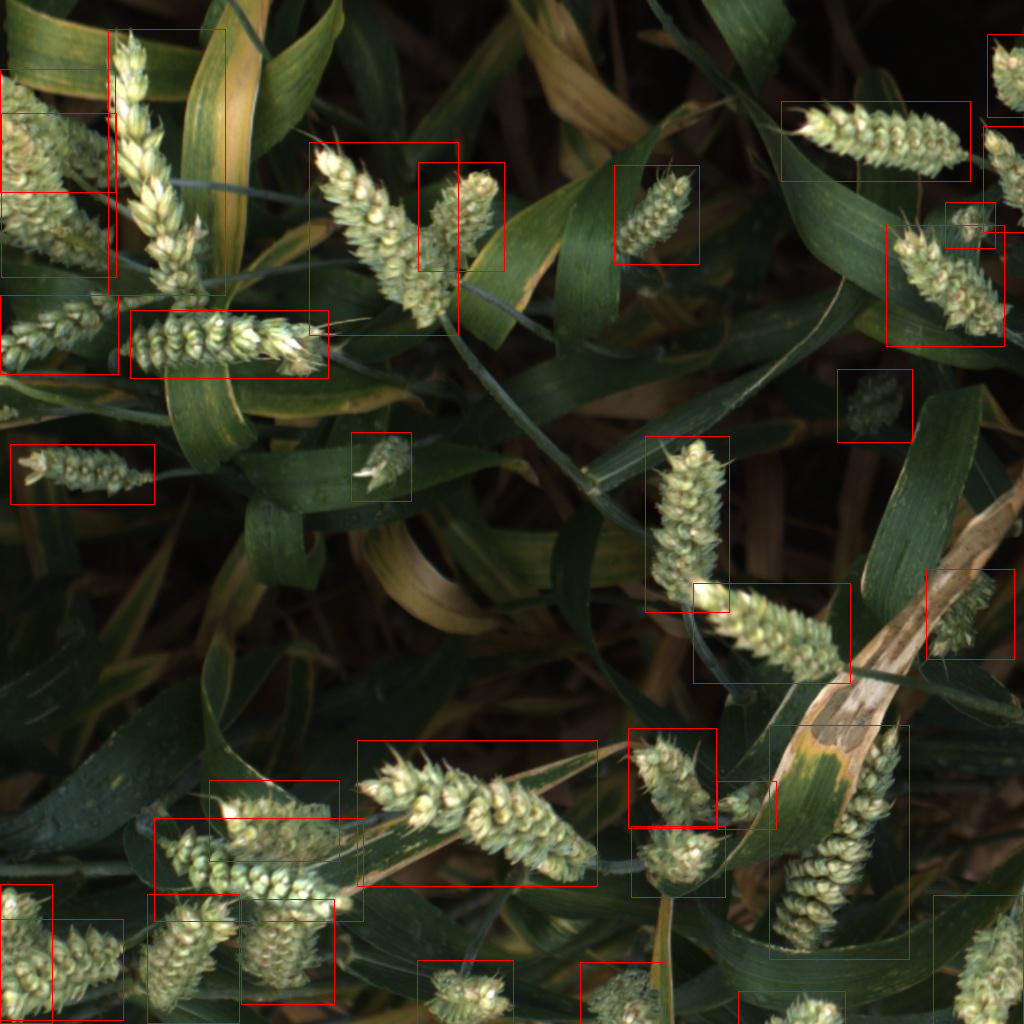

In [30]:
vsample = Image.fromarray(im)
draw = ImageDraw.Draw(vsample)
for box in boxes :
    draw.rectangle(list(box),fill=None,outline='red')
vsample

In [32]:
# Save the model state
torch.save(model.state_dict(), 'modified_fasterrcnn_resnet50_fpn.pth')

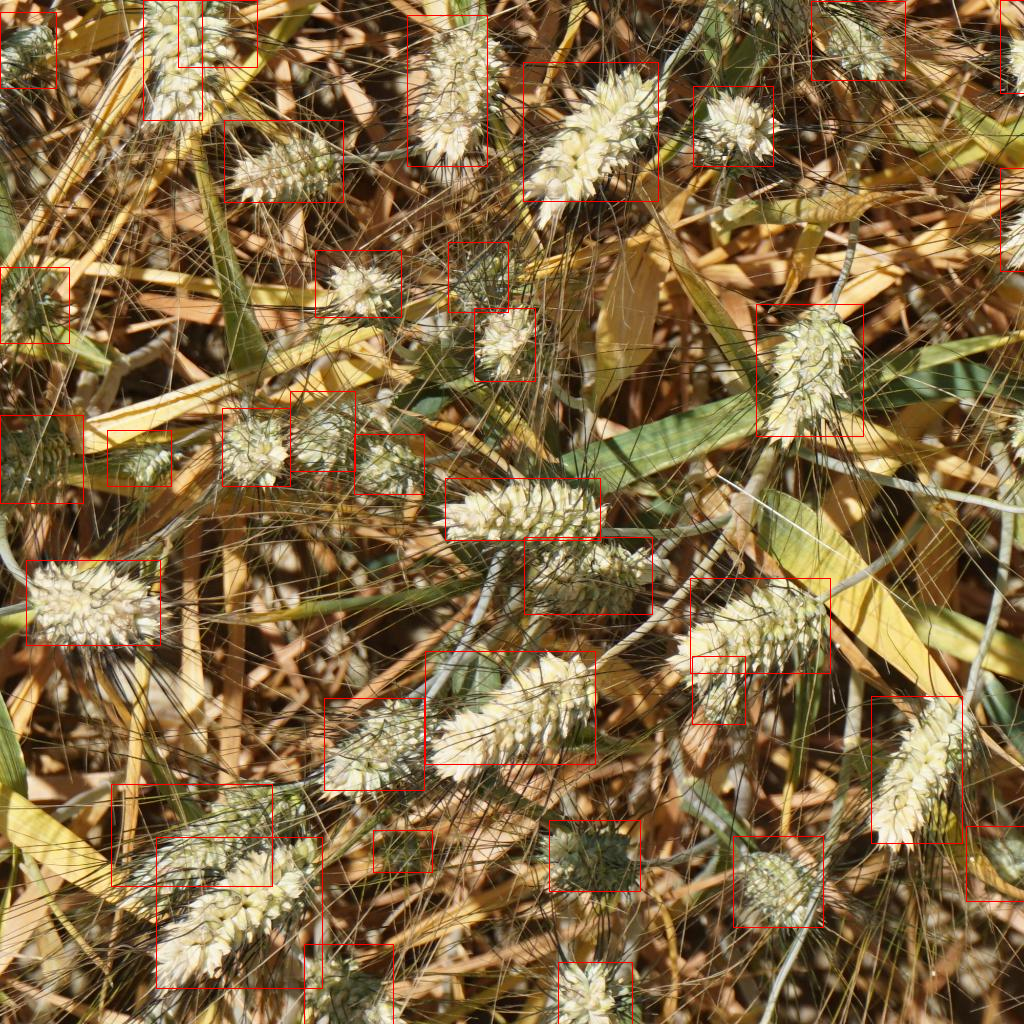

In [33]:
model.eval()
data = iter(val_dl).__next__()

img= data[0][0]
boxes=data[0][1]['boxes']
labels=data[0][1]['label']

output = model([img.to(device)])

out_bbox=output[0]['boxes']
out_scores=output[0]['scores']

keep = torchvision.ops.nms(out_bbox,out_scores,0.45)

out_bbox.shape , keep.shape
im = (img.permute(1,2,0).cpu().detach().numpy()*255).astype('uint8')

vsample = Image.fromarray(im)
draw = ImageDraw.Draw(vsample)
for box in boxes :
    draw.rectangle(list(box),fill=None,outline='red')
vsample

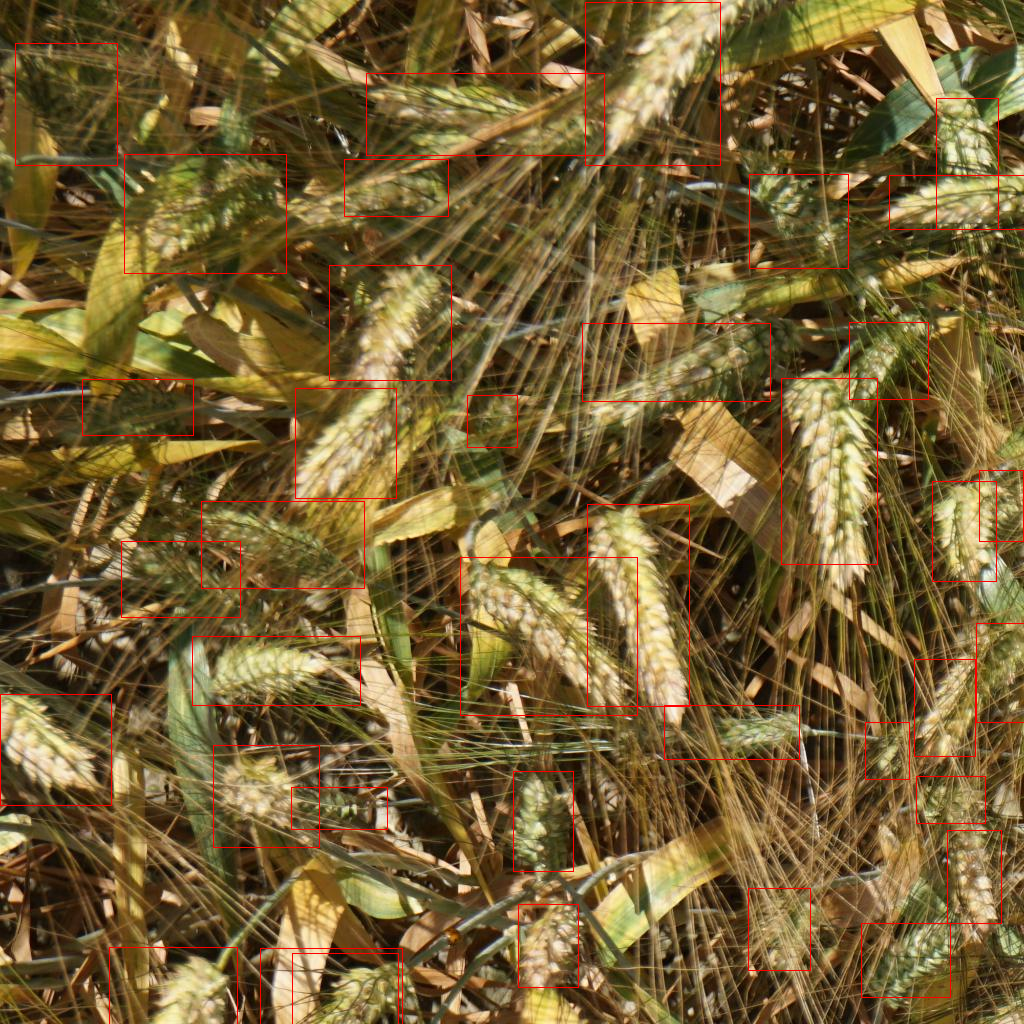

In [34]:
model.eval()
data = iter(val_dl).__next__()

img= data[0][0]
boxes=data[0][1]['boxes']
labels=data[0][1]['label']

output = model([img.to(device)])

out_bbox=output[0]['boxes']
out_scores=output[0]['scores']

keep = torchvision.ops.nms(out_bbox,out_scores,0.45)

out_bbox.shape , keep.shape
im = (img.permute(1,2,0).cpu().detach().numpy()*255).astype('uint8')

vsample = Image.fromarray(im)
draw = ImageDraw.Draw(vsample)
for box in boxes :
    draw.rectangle(list(box),fill=None,outline='red')
vsample

In [37]:
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Function to create the model and replace the classifier head
def create_model(num_classes):
    # Load a pre-trained model
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=False)
    
    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    
    # Replace the pre-trained head with a new one (adjusting for the number of classes)
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    return model

# Specify the number of classes (1 class + background)
num_classes = 2

# Create a model instance
model2 = create_model(num_classes)

# Load the saved model state dictionary
model2.load_state_dict(torch.load('/kaggle/working/modified_fasterrcnn_resnet50_fpn.pth'))

# Move the model to the specified device
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model2.to(device)

# Now the model is ready to be used for inference or further training

RuntimeError: Error(s) in loading state_dict for FasterRCNN:
	size mismatch for roi_heads.box_predictor.cls_score.weight: copying a param with shape torch.Size([91, 1024]) from checkpoint, the shape in current model is torch.Size([2, 1024]).
	size mismatch for roi_heads.box_predictor.cls_score.bias: copying a param with shape torch.Size([91]) from checkpoint, the shape in current model is torch.Size([2]).
	size mismatch for roi_heads.box_predictor.bbox_pred.weight: copying a param with shape torch.Size([364, 1024]) from checkpoint, the shape in current model is torch.Size([8, 1024]).
	size mismatch for roi_heads.box_predictor.bbox_pred.bias: copying a param with shape torch.Size([364]) from checkpoint, the shape in current model is torch.Size([8]).

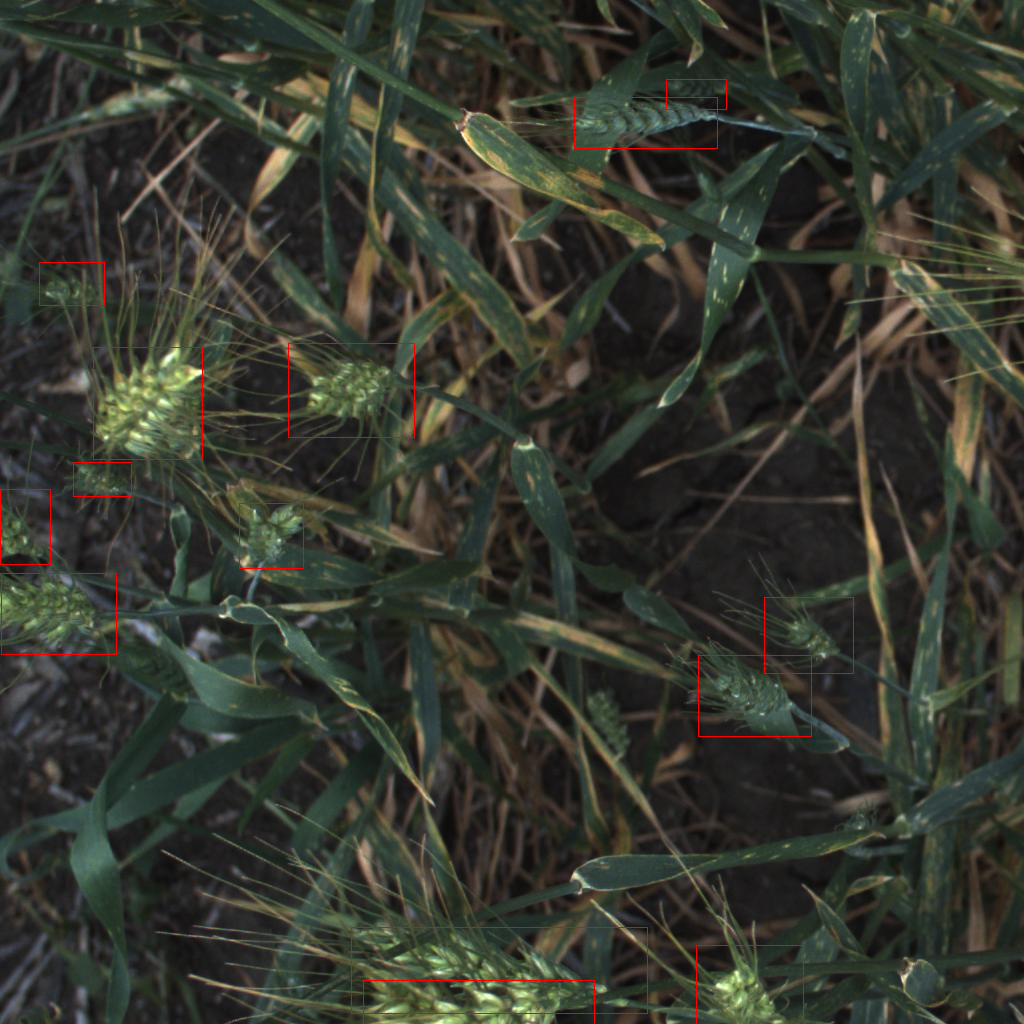

In [36]:
model2.eval()
data = iter(val_dl).__next__()

img= data[0][0]
boxes=data[0][1]['boxes']
labels=data[0][1]['label']

output = model([img.to(device)])

out_bbox=output[0]['boxes']
out_scores=output[0]['scores']

keep = torchvision.ops.nms(out_bbox,out_scores,0.45)

out_bbox.shape , keep.shape
im = (img.permute(1,2,0).cpu().detach().numpy()*255).astype('uint8')

vsample = Image.fromarray(im)
draw = ImageDraw.Draw(vsample)
for box in boxes :
    draw.rectangle(list(box),fill=None,outline='red')
vsample